In [4]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'memit'))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
os.chdir(PROJECT_ROOT / 'memit')
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f"Working directory: {os.getcwd()}")
print(f"Project root: {PROJECT_ROOT}")

Working directory: C:\Users\bhugg\OneDrive\Documents\GitHub\LLPV\memit
Project root: C:\Users\bhugg\OneDrive\Documents\GitHub\LLPV


In [21]:
MODEL_NAME = "gpt2"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    device_map="auto"
)

print(f"Model loaded on {next(model.parameters()).device}")

Loading gpt2...
Model loaded on cuda:0


In [22]:
edit_request = {
    "prompt": "{} is located in",
    "subject": "The Eiffel Tower",
    "target_new": {"str": " Rome"},
    "case_id": 1
}

prompt = edit_request["prompt"].format(edit_request["subject"])
print(f"Full prompt: '{prompt}'")

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=10, do_sample=False)
print("Before edit:")
print(tokenizer.decode(outputs[0]))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Full prompt: 'The Eiffel Tower is located in'
Before edit:
The Eiffel Tower is located in the heart of the city, and is the only


In [23]:
from src.drift.baseline import BaselinePromptsManager

baseline_manager = BaselinePromptsManager()
print(f"Using {len(baseline_manager.prompts)} baseline prompts")
baseline_manager.compute_baselines(model, tokenizer, DEVICE)

Using 28 baseline prompts
Computing baselines for 28 prompts...
  Processed 10/28 prompts
  Processed 20/28 prompts
Baselines computed for 28 prompts


In [27]:
import json

with open('../memit/hparams/ROME/gpt2-xl.json', 'r') as f:
    hparams_dict = json.load(f)

hparams_dict['layers'] = [5]
hparams_dict['v_loss_layer'] = 11
hparams_dict['rewrite_module_tmp'] = 'transformer.h.{}.mlp.c_proj'
hparams_dict['layer_module_tmp'] = 'transformer.h.{}'
hparams_dict['mlp_module_tmp'] = 'transformer.h.{}.mlp'
hparams_dict['attn_module_tmp'] = 'transformer.h.{}.attn'
hparams_dict['ln_f_module'] = 'transformer.ln_f'
hparams_dict['lm_head_module'] = 'lm_head'

with open('../memit/hparams/ROME/gpt2-small.json', 'w') as f:
    json.dump(hparams_dict, f, indent=2)

print("Created gpt2-small.json")
print(f"  layers: {hparams_dict['layers']}")
print(f"  v_loss_layer: {hparams_dict['v_loss_layer']}")

Created gpt2-small.json
  layers: [5]
  v_loss_layer: 11


In [28]:
from rome.rome_hparams import ROMEHyperParams
from src.editing.rome_exposed import execute_rome_exposed

hparams = ROMEHyperParams.from_json('hparams/ROME/gpt2-small.json')
hparams.mom2_n_samples = 1000
print(f"ROME layers: {hparams.layers}")
print(f"Target module: {hparams.rewrite_module_tmp}")
weight_update = execute_rome_exposed(model, tokenizer, edit_request, hparams)
print("\nWeight update computed:")
print(f"  Parameters: {list(weight_update.deltas.keys())}")
print(f"  Total norm: {weight_update.total_norm:.4f}")

ROME layers: [5]
Target module: transformer.h.{}.mlp.c_proj
Computing ROME deltas for: [The Eiffel Tower is located in] -> [ Rome]
Computing left vector (u)...
Selected u projection object The Eiffel Tower
Retrieving inverse covariance statistics for gpt2 @ transformer.h.5.mlp.c_proj. The result will be cached to avoid repetitive computation.
Attempting to download gpt2/wikipedia_stats/transformer.h.5.mlp.c_proj_float32_mom2_1000.npz from https://memit.baulab.info/data/stats/gpt2/wikipedia_stats/transformer.h.5.mlp.c_proj_float32_mom2_1000.npz.
Unable to download due to HTTP Error 404: Not Found. Computing locally....


  0%|          | 0/10 [00:00<?, ?it/s]

Left vector shape: torch.Size([3072])
Computing right vector (v)
Lookup index found: 4 | Sentence: The Eiffel Tower is located in | Token:  Tower
Rewrite layer is 5
Tying optimization objective to 11
Recording initial value of v*
loss 7.655 = 7.655 + 0.0 + 0.0 avg prob of [ Rome] 0.0005360182258300483
loss 5.456 = 5.424 + 0.004 + 0.027 avg prob of [ Rome] 0.005475239362567663
loss 2.79 = 2.73 + 0.014 + 0.046 avg prob of [ Rome] 0.07827209681272507
loss 0.64 = 0.557 + 0.021 + 0.063 avg prob of [ Rome] 0.5788587927818298
loss 0.126 = 0.019 + 0.03 + 0.078 avg prob of [ Rome] 0.9815757274627686
loss 0.125 = 0.001 + 0.033 + 0.091 avg prob of [ Rome] 0.9991780519485474
loss 0.137 = 0.0 + 0.033 + 0.104 avg prob of [ Rome] 0.9996252655982971
loss 0.149 = 0.0 + 0.034 + 0.115 avg prob of [ Rome] 0.999695360660553
loss 0.16 = 0.0 + 0.035 + 0.124 avg prob of [ Rome] 0.9996486902236938
loss 0.16 = 0.0 + 0.034 + 0.126 avg prob of [ Rome] 0.9995651245117188
loss 0.159 = 0.001 + 0.033 + 0.126 avg prob

In [29]:
from src.drift.controller import DriftController
from src.editing.weight_update import apply_weight_update_context
from src.drift.metrics import compute_last_token_kl, compute_edit_success

alpha_values = [0.0, 0.25, 0.5, 0.75, 1.0]
results = []

for alpha in alpha_values:
    with apply_weight_update_context(model, weight_update, alpha=alpha):
        # Measure drift
        drift = compute_last_token_kl(
            model, tokenizer,
            baseline_manager.prompts,
            baseline_manager.baseline_logits,
            DEVICE
        )
        
        success = compute_edit_success(
            model, tokenizer,
            prompt,
            edit_request["target_new"]["str"],
            device=DEVICE
        )
        
        results.append({
            'alpha': alpha,
            'drift': drift.mean_kl,
            'target_rank': success.rank_after
        })
        
        print(f"Alpha={alpha:.2f}: Drift={drift.mean_kl:.6f}, Target Rank={success.rank_after}")

Alpha=0.00: Drift=0.000000, Target Rank=92
Alpha=0.25: Drift=0.001226, Target Rank=6
Alpha=0.50: Drift=0.005220, Target Rank=1
Alpha=0.75: Drift=0.012378, Target Rank=1
Alpha=1.00: Drift=0.022960, Target Rank=1


In [30]:
controller = DriftController(
    baseline_manager=baseline_manager,
    drift_threshold=0.1,
    device=DEVICE
)

opt_result = controller.find_optimal_alpha(
    model, tokenizer, weight_update, edit_request
)

print(f"\nOptimization Result:")
print(f"  Optimal alpha: {opt_result.optimal_alpha:.4f}")
print(f"  Final drift: {opt_result.final_drift.mean_kl:.6f}")
print(f"  Converged: {opt_result.converged}")

Baseline target log prob: -7.1886
Starting binary search for optimal alpha...
  Drift threshold: 0.1
  Edit success threshold: 1.0
  Iter 0: alpha=0.5000, drift=0.005220, improvement=7.1432
  Iter 1: alpha=0.7500, drift=0.012378, improvement=7.1859
  Iter 2: alpha=0.8750, drift=0.017232, improvement=7.1842
  Iter 3: alpha=0.9375, drift=0.019986, improvement=7.1824
  Iter 4: alpha=0.9688, drift=0.021446, improvement=7.1813
  Iter 5: alpha=0.9844, drift=0.022196, improvement=7.1807
  Iter 6: alpha=0.9922, drift=0.022577, improvement=7.1804
  Converged at alpha=0.9922

Optimization Result:
  Optimal alpha: 0.9922
  Final drift: 0.022577
  Converged: True


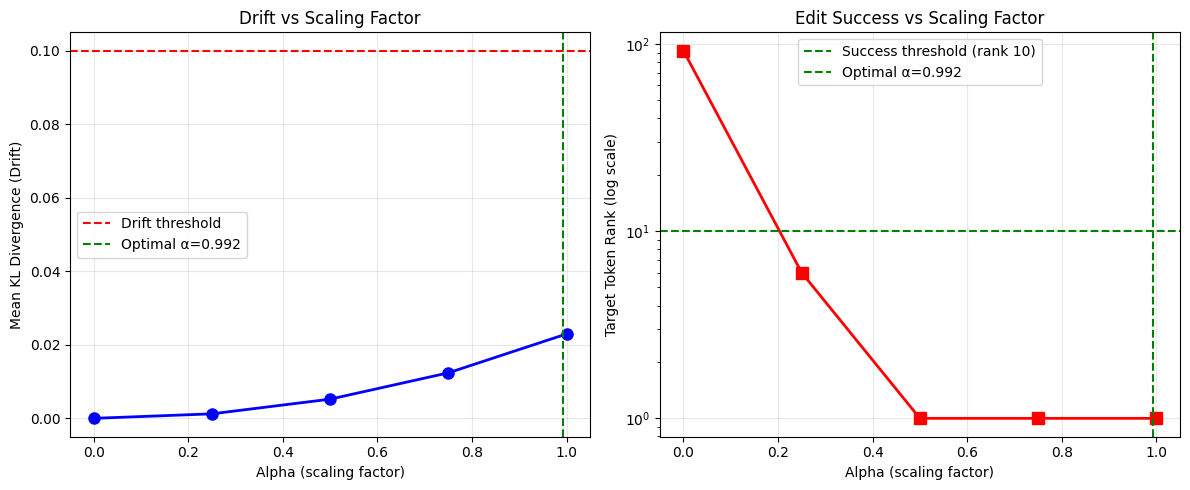

Plot saved to C:\Users\bhugg\OneDrive\Documents\GitHub\LLPV\results\demo_analysis.png


In [31]:
import matplotlib.pyplot as plt
import os

os.makedirs(str(PROJECT_ROOT / 'results'), exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


alphas = [r['alpha'] for r in results]
drifts = [r['drift'] for r in results]
ranks = [r['target_rank'] for r in results]

axes[0].plot(alphas, drifts, 'b-o', linewidth=2, markersize=8)
axes[0].axhline(y=0.1, color='r', linestyle='--', label='Drift threshold')
axes[0].axvline(x=opt_result.optimal_alpha, color='g', linestyle='--', label=f'Optimal α={opt_result.optimal_alpha:.3f}')
axes[0].set_xlabel('Alpha (scaling factor)')
axes[0].set_ylabel('Mean KL Divergence (Drift)')
axes[0].set_title('Drift vs Scaling Factor')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(alphas, ranks, 'r-s', linewidth=2, markersize=8)
axes[1].axhline(y=10, color='g', linestyle='--', label='Success threshold (rank 10)')
axes[1].axvline(x=opt_result.optimal_alpha, color='g', linestyle='--', label=f'Optimal α={opt_result.optimal_alpha:.3f}')
axes[1].set_xlabel('Alpha (scaling factor)')
axes[1].set_ylabel('Target Token Rank (log scale)')
axes[1].set_title('Edit Success vs Scaling Factor')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'results' / 'demo_analysis.png'), dpi=150)
plt.show()
print(f"Plot saved to {PROJECT_ROOT / 'results' / 'demo_analysis.png'}")

In [36]:
from src.editing.weight_update import apply_weight_update

model = apply_weight_update(model, weight_update, alpha=opt_result.optimal_alpha)

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=10, do_sample=False)
print("After stabilized edit:")
print(tokenizer.decode(outputs[0]))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


After stabilized edit:
The Eiffel Tower is located in Rome

Eius

Eius

